# Week 7 Implementation: ES Adaptation Under Environment Perturbation

**Date:** February 25, 2026  
**Course:** STAT 4830

This notebook studies transfer adaptation with Evolution Strategies (ES):
1. Pretrain a policy on baseline GridWorld.
2. Perturb the environment by moving grid cells (local layout shifts).
3. Continue training from the same pretrained checkpoint using:
   - **Full ES** (`param_mode='all'`)
   - **LoRA-only ES** (`param_mode='lora'`, pretrained base frozen)

The focus is adaptation speed, not just final performance.

## Problem Setup

### Adaptation Question

**Goal:** Measure how quickly each method re-learns a good policy after an environment shift.

**Methods compared from the same initialization:**
1. **Full ES adaptation** (`param_mode='all'`)
2. **LoRA-only ES adaptation** (`param_mode='lora'`)

**Environment shift:** controlled layout perturbation (slight obstacle/goal cell moves) at curriculum levels.

**Fairness controls:**
- Same pretrained checkpoint for both methods
- Same perturbed map instance per seed
- Same ES hyperparameters and evaluation schedule

### Mathematical Formulation

We optimize expected return:
$$
\max_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} r_t\right]
$$

ES gradient estimator:
$$
\nabla_\theta J(\theta) \approx \frac{1}{N\sigma}\sum_{i=1}^{N} F_i\, s(\epsilon_i)
$$
where $s(\epsilon)$ is the score-function term for the selected noise distribution.

For rank-$k$ LoRA on each linear layer:
$$
W' = W + \alpha\, B A
$$
with factors $A \in \mathbb{R}^{k \times d_{\text{in}}}$ and $B \in \mathbb{R}^{d_{\text{out}} \times k}$ (rank $\le k$). In LoRA-only mode, ES updates only adapter factors while $W$ is frozen.

### Data Requirements

**Environment:**
- Grid size: 8x8
- Obstacles: 8
- State space: one-hot position (64 dims)
- Action space: 4 actions
- Max steps per episode: 50

**Reward scheme:**
- **Training:** distance-based shaped rewards (dense signal)
- **Evaluation:** sparse reward GridWorld

**Perturbation protocol:**
- Layout perturbation levels (fraction of obstacle cells moved): `0.00`, `0.25`, `0.50`, `0.75`
- Cell moves are local (small shifts) to support curriculum-style progression
- Same world seed pairings for both methods at each level
- Evaluate adaptation over a fixed post-perturbation ES budget

### Success Metrics

**Primary adaptation metrics:**
1. **Time-to-threshold**: first eval point where success reaches `0.6`, `0.8`, `0.9`
2. **AUC(success vs iteration)** over adaptation horizon
3. **Threshold interactions**: cumulative environment interactions needed to hit threshold

**Secondary:**
4. Final `eval_success`, `eval_reward`, and `eval_steps`

**Diagnostics:**
5. `gradient_norm`, `avg_fitness`, and `fitness_std` trends

## Implementation

In [ ]:
# All required imports
import sys
sys.path.append('../src')

import time
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from gridworld import GridWorld, PolicyNetwork
from es_gridworld import train_es, evaluate_policy

# Reproducibility
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)
    # Improve repeatability on GPU (with potential speed trade-off).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

print('Imports successful!')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

Imports successful!
PyTorch version: 2.10.0+cpu
Device: cpu


### Environment Implementation

Base environment: 8x8, obstacles=8, max_steps=50
State shape: (64,), action space: 4
Perturbation levels (layout move fraction): [0.0, 0.25, 0.5, 0.75]
Seeds: [11, 33, 55]


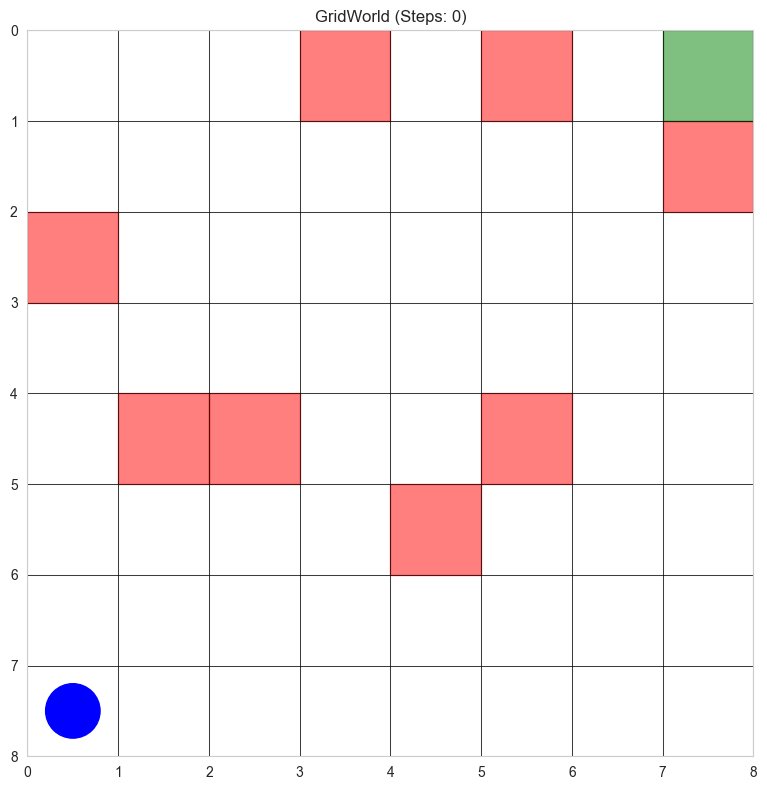

In [ ]:
# Distance-based reward shaping (same strategy as Week 4)
class ShapedRewardEnvComparison(GridWorld):
    """GridWorld with distance-based reward shaping."""

    def reset(self):
        state = super().reset()
        self.prev_dist = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])
        return state

    def step(self, action):
        state, reward, done, info = super().step(action)
        curr_dist = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])
        shaped_reward = reward + 0.2 * (self.prev_dist - curr_dist) - 0.01
        self.prev_dist = curr_dist
        return state, shaped_reward, done, info


class PerturbedLayoutGridWorld(GridWorld):
    """GridWorld where obstacle/goal cells are moved slightly from a source layout."""

    def __init__(self, layout_perturb_level: float = 0.0, max_shift: int = 1, **kwargs):
        super().__init__(**kwargs)
        self.layout_perturb_level = float(layout_perturb_level)
        self.max_shift = int(max_shift)

    def _sample_shifted_cell(self, base_pos, forbidden):
        """Sample a nearby valid cell around base_pos."""
        for _ in range(50):
            dx = int(self.rng.randint(-self.max_shift, self.max_shift + 1))
            dy = int(self.rng.randint(-self.max_shift, self.max_shift + 1))
            nx = int(np.clip(base_pos[0] + dx, 0, self.size - 1))
            ny = int(np.clip(base_pos[1] + dy, 0, self.size - 1))
            cand = (nx, ny)
            if cand not in forbidden:
                return cand
        return base_pos

    def perturb_from_source_layout(self, source_env: GridWorld):
        """
        Move a fraction of obstacle cells and optionally the goal cell.
        Larger layout_perturb_level => more moved cells and larger shift radius.
        """
        self.start_pos = source_env.start_pos
        self.goal_pos = source_env.goal_pos

        source_obstacles = list(source_env.obstacles)
        n_obs = len(source_obstacles)
        if n_obs == 0 or self.layout_perturb_level <= 0:
            self.obstacles = set(source_obstacles)
            return

        move_fraction = float(np.clip(self.layout_perturb_level, 0.0, 1.0))
        n_to_move = int(np.round(move_fraction * n_obs))
        n_to_move = min(max(n_to_move, 1), n_obs)

        move_idx = set(self.rng.choice(np.arange(n_obs), size=n_to_move, replace=False).tolist())
        new_obstacles = []

        for idx, obs in enumerate(source_obstacles):
            if idx not in move_idx:
                new_obstacles.append(obs)
                continue

            forbidden = {self.start_pos, self.goal_pos, *new_obstacles}
            shifted = self._sample_shifted_cell(obs, forbidden)
            new_obstacles.append(shifted)

        # Optionally shift goal by one local move for harder curriculum levels.
        if self.layout_perturb_level >= 0.5:
            forbidden = {self.start_pos, *new_obstacles}
            self.goal_pos = self._sample_shifted_cell(self.goal_pos, forbidden)

        self.obstacles = set(new_obstacles)


class ShapedPerturbedLayoutGridWorld(PerturbedLayoutGridWorld):
    """Layout-perturbed GridWorld plus dense distance-based shaping."""

    def reset(self):
        state = super().reset()
        self.prev_dist = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])
        return state

    def step(self, action):
        state, reward, done, info = super().step(action)
        curr_dist = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])
        shaped_reward = reward + 0.2 * (self.prev_dist - curr_dist) - 0.01
        self.prev_dist = curr_dist
        return state, shaped_reward, done, info


def align_world_layout(target_env: GridWorld, source_env: GridWorld):
    """Copy obstacle/start/goal layout to ensure paired comparisons."""
    target_env.goal_pos = source_env.goal_pos
    target_env.start_pos = source_env.start_pos
    target_env.obstacles = set(source_env.obstacles)


# Global experiment controls
GRID_SIZE = 8
N_OBSTACLES = 8
MAX_STEPS = 50
PERTURB_LEVELS = [0.0, 0.25, 0.50, 0.75]
SEEDS = [11, 33, 55]

# Baseline example env (for quick sanity checks)
example_env = ShapedRewardEnvComparison(size=GRID_SIZE, n_obstacles=N_OBSTACLES, max_steps=MAX_STEPS, seed=SEEDS[0])
state = example_env.reset()

print(f'Base environment: {GRID_SIZE}x{GRID_SIZE}, obstacles={N_OBSTACLES}, max_steps={MAX_STEPS}')
print(f'State shape: {state.shape}, action space: {example_env.n_actions}')
print(f'Perturbation levels (layout move fraction): {PERTURB_LEVELS}')
print(f'Seeds: {SEEDS}')

example_env.render();

### Policy Setup: Standard vs Rank-1 LoRA

In [ ]:
state_dim = example_env._get_state().shape[0]
action_dim = example_env.n_actions

standard_policy = PolicyNetwork(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=64,
    n_layers=2,
    use_lora=False
).to(device)

lora_policy = PolicyNetwork(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=64,
    n_layers=2,
    use_lora=True,
    lora_rank=1,
    lora_alpha=1.0,
    lora_init_scale=1e-3
).to(device)

total_standard = sum(p.numel() for p in standard_policy.parameters())
total_lora_model = sum(p.numel() for p in lora_policy.parameters())
lora_trainable = lora_policy.count_lora_parameters()

print('Parameter counts:')
print(f'  Full ES searched params: {total_standard}')
print(f'  LoRA-only searched params: {lora_trainable}')
print(f'  Search-space compression: {total_standard / lora_trainable:.2f}x')

Parameter counts:
  Full ES searched params: 8580
  LoRA-only searched params: 324
  Search-space compression: 26.48x


### ES Experiment Utilities

In [ ]:
PRETRAIN_CFG = {
    'N': 50,
    'sigma': 0.10,
    'alpha': 0.05,
    'n_iterations': 80,
    'n_eval_episodes': 5,
    'max_steps': MAX_STEPS,
    'eval_every': 5,
    'noise_type': 'gaussian',
    # Optional dynamic budget for pretraining
    'use_early_stop': True,
    'min_iterations': 40,
    'max_iterations': 160,
    'chunk_iterations': 20,
    'stop_success': 0.90,
    # Source-quality gate
    'gate_min_success': 0.80,
    'enforce_gate': True,
    # Behavior when pretraining does not meet gate at max budget:
    # - 'skip': record run as skipped and continue batch
    # - 'raise': fail fast with clear diagnostics
    'on_gate_fail': 'skip'
}

ADAPT_CFG = {
    'N': 50,
    'sigma': 0.10,
    'alpha': 0.05,
    'n_iterations': 80,
    'n_eval_episodes': 5,
    'max_steps': MAX_STEPS,
    'eval_every': 5,
    'noise_type': 'gaussian',
    # Optional dynamic budget for adaptation
    'use_early_stop': False,
    'min_iterations': 20,
    'max_iterations': 120,
    'chunk_iterations': 20,
    'stop_success': 0.90
}


EMPTY_HISTORY = {
    'iteration': [],
    'avg_fitness': [],
    'eval_reward': [],
    'eval_success': [],
    'eval_steps': [],
    'gradient_norm': [],
    'fitness_std': [],
    'env_interactions': [],
    'cumulative_env_interactions': []
}


def make_empty_history():
    return {k: [] for k in EMPTY_HISTORY.keys()}


def set_run_seed(seed: int):
    """Reset random seeds for deterministic per-run behavior."""
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_policy(use_lora: bool, lora_rank: int = 1):
    return PolicyNetwork(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=64,
        n_layers=2,
        use_lora=use_lora,
        lora_rank=lora_rank,
        lora_alpha=1.0,
        lora_init_scale=1e-3
    ).to(device)


def copy_pretrained_into_lora_base(pretrained_full_policy, lora_policy):
    """Copy pretrained Linear weights into LoRA base layers."""
    src_linears = [m for m in pretrained_full_policy.network if isinstance(m, torch.nn.Linear)]
    dst_lora_wrappers = [m for m in lora_policy.network if hasattr(m, 'base')]

    if len(src_linears) != len(dst_lora_wrappers):
        raise ValueError('Architecture mismatch while loading pretrained weights into LoRA base.')

    for src, dst in zip(src_linears, dst_lora_wrappers):
        dst.base.weight.data.copy_(src.weight.data)
        if src.bias is not None and dst.base.bias is not None:
            dst.base.bias.data.copy_(src.bias.data)


def make_source_envs(seed: int):
    train_env = ShapedRewardEnvComparison(
        size=GRID_SIZE,
        n_obstacles=N_OBSTACLES,
        max_steps=MAX_STEPS,
        seed=seed
    )
    eval_env = GridWorld(
        size=GRID_SIZE,
        n_obstacles=N_OBSTACLES,
        max_steps=MAX_STEPS,
        seed=seed
    )
    align_world_layout(eval_env, train_env)
    return train_env, eval_env


def make_target_envs(seed: int, layout_perturb_level: float, source_layout_env: GridWorld):
    train_env = ShapedPerturbedLayoutGridWorld(
        size=GRID_SIZE,
        n_obstacles=N_OBSTACLES,
        max_steps=MAX_STEPS,
        seed=seed,
        layout_perturb_level=layout_perturb_level,
        max_shift=1
    )
    eval_env = PerturbedLayoutGridWorld(
        size=GRID_SIZE,
        n_obstacles=N_OBSTACLES,
        max_steps=MAX_STEPS,
        seed=seed,
        layout_perturb_level=layout_perturb_level,
        max_shift=1
    )

    # Start from the source map, then apply controlled local cell moves.
    align_world_layout(train_env, source_layout_env)
    align_world_layout(eval_env, source_layout_env)
    train_env.perturb_from_source_layout(source_layout_env)
    eval_env.perturb_from_source_layout(source_layout_env)
    return train_env, eval_env


def _append_history(base_hist, new_hist, iter_offset: int = 0, interaction_offset: float = 0.0):
    if base_hist is None:
        base_hist = {k: [] for k in new_hist.keys()}

    n_points = len(new_hist['iteration'])
    for i in range(n_points):
        for key in new_hist.keys():
            value = new_hist[key][i]
            if key == 'iteration':
                value = int(value + iter_offset)
            elif key == 'cumulative_env_interactions':
                value = float(value + interaction_offset)
            base_hist[key].append(value)

    return base_hist


def train_es_with_budget(
    policy,
    train_env,
    eval_env,
    cfg,
    param_mode: str,
    eval_episodes: int = 30
):
    use_early_stop = bool(cfg.get('use_early_stop', False))

    if not use_early_stop:
        history = train_es(
            policy=policy,
            env=train_env,
            N=cfg['N'],
            sigma=cfg['sigma'],
            alpha=cfg['alpha'],
            n_iterations=cfg['n_iterations'],
            n_eval_episodes=cfg['n_eval_episodes'],
            max_steps=cfg['max_steps'],
            eval_every=cfg['eval_every'],
            verbosity=0,
            noise_type=cfg['noise_type'],
            param_mode=param_mode
        )
        final_reward, final_success, final_steps = evaluate_policy(
            policy=policy,
            env=eval_env,
            n_episodes=eval_episodes,
            max_steps=cfg['max_steps'],
            deterministic=True
        )
        return history, int(cfg['n_iterations']), (float(final_reward), float(final_success), float(final_steps))

    max_iterations = int(cfg.get('max_iterations', cfg['n_iterations']))
    min_iterations = int(cfg.get('min_iterations', 0))
    chunk_iterations = int(cfg.get('chunk_iterations', cfg['eval_every']))
    if max_iterations <= 0:
        raise ValueError('max_iterations must be positive when use_early_stop=True')
    if min_iterations < 0:
        raise ValueError('min_iterations must be non-negative when use_early_stop=True')
    if min_iterations > max_iterations:
        raise ValueError('min_iterations cannot exceed max_iterations when use_early_stop=True')
    if chunk_iterations <= 0:
        raise ValueError('chunk_iterations must be positive when use_early_stop=True')
    stop_success = cfg.get('stop_success', None)

    total_history = None
    total_iters = 0
    last_eval = (np.nan, np.nan, np.nan)

    while total_iters < max_iterations:
        this_chunk = min(chunk_iterations, max_iterations - total_iters)
        chunk_history = train_es(
            policy=policy,
            env=train_env,
            N=cfg['N'],
            sigma=cfg['sigma'],
            alpha=cfg['alpha'],
            n_iterations=this_chunk,
            n_eval_episodes=cfg['n_eval_episodes'],
            max_steps=cfg['max_steps'],
            eval_every=cfg['eval_every'],
            verbosity=0,
            noise_type=cfg['noise_type'],
            param_mode=param_mode
        )

        iter_offset = total_iters
        if total_history is None or len(total_history['cumulative_env_interactions']) == 0:
            interaction_offset = 0.0
        else:
            interaction_offset = float(total_history['cumulative_env_interactions'][-1])

        total_history = _append_history(
            total_history,
            chunk_history,
            iter_offset=iter_offset,
            interaction_offset=interaction_offset
        )

        total_iters += this_chunk

        eval_reward, eval_success, eval_steps = evaluate_policy(
            policy=policy,
            env=eval_env,
            n_episodes=eval_episodes,
            max_steps=cfg['max_steps'],
            deterministic=True
        )
        last_eval = (float(eval_reward), float(eval_success), float(eval_steps))

        if (
            stop_success is not None
            and total_iters >= min_iterations
            and eval_success >= float(stop_success)
        ):
            break

    if total_history is None:
        total_history = make_empty_history()

    return total_history, int(total_iters), last_eval


def pretrain_source_policy(seed: int):
    # Deterministic source pretraining per seed.
    set_run_seed(seed)

    train_env, eval_env = make_source_envs(seed)
    pretrained_policy = make_policy(use_lora=False)

    _, pretrain_iters, (src_reward, src_success, src_steps) = train_es_with_budget(
        policy=pretrained_policy,
        train_env=train_env,
        eval_env=eval_env,
        cfg=PRETRAIN_CFG,
        param_mode='all',
        eval_episodes=30
    )

    gate_threshold = float(PRETRAIN_CFG['gate_min_success'])
    gate_passed = bool(src_success >= gate_threshold)
    max_budget = int(PRETRAIN_CFG.get('max_iterations', PRETRAIN_CFG['n_iterations']))
    at_max_budget = bool(PRETRAIN_CFG.get('use_early_stop', False)) and (int(pretrain_iters) >= max_budget)

    return pretrained_policy, train_env, {
        'pretrain_reward': float(src_reward),
        'pretrain_success': float(src_success),
        'pretrain_steps': float(src_steps),
        'pretrain_iterations': int(pretrain_iters),
        'pretrain_max_iterations': int(max_budget),
        'pretrain_hit_max_budget': int(at_max_budget),
        'pretrain_gate_threshold': gate_threshold,
        'pretrain_gate_passed': int(gate_passed),
        'pretrain_gate_status': 'pass' if gate_passed else 'fail',
        'pretrain_failed': int(not gate_passed)
    }


def first_threshold_hit(history, threshold: float):
    n = min(
        len(history.get('eval_success', [])),
        len(history.get('iteration', [])),
        len(history.get('cumulative_env_interactions', []))
    )
    for idx in range(n):
        value = history['eval_success'][idx]
        if value >= threshold:
            return int(history['iteration'][idx]), float(history['cumulative_env_interactions'][idx])
    return None, None


def adaptation_auc(history):
    x = np.asarray(history['iteration'], dtype=np.float64)
    y = np.asarray(history['eval_success'], dtype=np.float64)
    if len(x) < 2:
        return float('nan')

    x_span = float(x[-1] - x[0])
    if x_span <= 0.0:
        return float('nan')

    return float(np.trapezoid(y, x) / x_span)


def run_adaptation(seed: int, perturb_std: float, method: str, source_bundle=None):
    # Use one shared pretrained source per seed to keep full vs LoRA comparisons paired.
    if source_bundle is None:
        pretrained_policy, source_layout_env, pretrain_metrics = pretrain_source_policy(seed)
    else:
        pretrained_policy = source_bundle['pretrained_policy']
        source_layout_env = source_bundle['source_layout_env']
        pretrain_metrics = dict(source_bundle['pretrain_metrics'])

    gate_enforced = bool(PRETRAIN_CFG.get('enforce_gate', True))
    gate_fail_mode = str(PRETRAIN_CFG.get('on_gate_fail', 'skip')).lower().strip()
    if gate_fail_mode not in {'skip', 'raise'}:
        raise ValueError("PRETRAIN_CFG['on_gate_fail'] must be 'skip' or 'raise'")

    # Enforce source quality gate so adaptation only uses qualified source policies.
    if gate_enforced and int(pretrain_metrics['pretrain_gate_passed']) != 1:
        skip_reason = (
            f"pretrain_gate_failed(success={pretrain_metrics['pretrain_success']:.3f}, "
            f"threshold={pretrain_metrics['pretrain_gate_threshold']:.3f}, "
            f"iters={pretrain_metrics['pretrain_iterations']}/{pretrain_metrics['pretrain_max_iterations']}, "
            f"hit_max_budget={pretrain_metrics['pretrain_hit_max_budget']})"
        )

        if gate_fail_mode == 'raise':
            raise RuntimeError(
                f"Source pretraining gate failed for seed={seed}, perturb={perturb_std:.2f}, method={method}. "
                f"{skip_reason}"
            )

        row = {
            'seed': int(seed),
            'method': method,
            'perturb_std': float(perturb_std),
            'run_status': 'skipped',
            'runtime_sec': 0.0,
            'final_eval_reward': np.nan,
            'final_eval_success': np.nan,
            'final_eval_steps': np.nan,
            'final_grad_norm': np.nan,
            'final_fitness_std': np.nan,
            'auc_success': np.nan,
            'adapt_iterations': 0,
            'skipped_reason': skip_reason,
            **pretrain_metrics
        }
        for threshold in (0.6, 0.8, 0.9):
            row[f'time_to_{threshold:.1f}'] = np.nan
            row[f'interactions_to_{threshold:.1f}'] = np.nan

        return row, make_empty_history()

    # Keep adaptation tied to source seed s; layout perturbation is the only environment intervention.
    set_run_seed(seed)

    target_train_env, target_eval_env = make_target_envs(seed, perturb_std, source_layout_env)

    if method == 'full':
        policy = deepcopy(pretrained_policy).to(device)
        param_mode = 'all'
    elif method == 'lora':
        policy = make_policy(use_lora=True, lora_rank=1)
        copy_pretrained_into_lora_base(pretrained_policy, policy)
        param_mode = 'lora'
    else:
        raise ValueError("method must be 'full' or 'lora'")

    t0 = time.time()
    history, adapt_iters, (final_reward, final_success, final_steps) = train_es_with_budget(
        policy=policy,
        train_env=target_train_env,
        eval_env=target_eval_env,
        cfg=ADAPT_CFG,
        param_mode=param_mode,
        eval_episodes=40
    )
    elapsed = time.time() - t0

    row = {
        'seed': int(seed),
        'method': method,
        'perturb_std': float(perturb_std),
        'run_status': 'ok',
        'runtime_sec': float(elapsed),
        'final_eval_reward': float(final_reward),
        'final_eval_success': float(final_success),
        'final_eval_steps': float(final_steps),
        'final_grad_norm': float(history['gradient_norm'][-1]) if len(history['gradient_norm']) else np.nan,
        'final_fitness_std': float(history['fitness_std'][-1]) if len(history['fitness_std']) else np.nan,
        'auc_success': adaptation_auc(history),
        'adapt_iterations': int(adapt_iters),
        'skipped_reason': '',
        **pretrain_metrics
    }

    for threshold in (0.6, 0.8, 0.9):
        t_iter, t_interactions = first_threshold_hit(history, threshold)
        row[f'time_to_{threshold:.1f}'] = np.nan if t_iter is None else t_iter
        row[f'interactions_to_{threshold:.1f}'] = np.nan if t_interactions is None else t_interactions

    return row, history


print('Adaptation utilities ready (with source gate + optional dynamic iterations).')

Adaptation utilities ready (with source gate + optional dynamic iterations).


### Run Adaptation Experiment

For each source seed `s` and perturbation level:
1. Pretrain ES on the baseline GridWorld for `s`.
2. Build a perturbed target map by moving cells from that same source layout.
3. Adapt from the same pretrained weights with either:
   - **Full continuation**: continue ES over all parameters (`param_mode='all'`).
   - **LoRA adaptation**: keep the pretrained base weights and update LoRA parameters only (`param_mode='lora'`).

This cell produces:
- `results_df`: one row per run (seed, perturbation, method)
- `history_store`: trajectories for plotting adaptation dynamics

In [ ]:
rows = []
history_store = {}

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
total_runs = len(SEEDS) * len(PERTURB_LEVELS) * 2
run_idx = 0
start_all = time.time()

print(f'Training device: {device} ({device_name})')
print(f"Pretrain gate: min_success={PRETRAIN_CFG['gate_min_success']:.2f}, enforce={PRETRAIN_CFG.get('enforce_gate', True)}, on_fail={PRETRAIN_CFG.get('on_gate_fail', 'skip')}")
print(f'Running {total_runs} total adaptation runs...')

source_cache = {}
print('\nPretraining one shared source checkpoint per seed...')
for seed in SEEDS:
    source_policy, source_layout_env, pretrain_metrics = pretrain_source_policy(seed)
    source_cache[seed] = {
        'pretrained_policy': source_policy,
        'source_layout_env': source_layout_env,
        'pretrain_metrics': pretrain_metrics
    }
    print(
        f"  Seed {seed}: source pretrain success={pretrain_metrics['pretrain_success']:.1%} "
        f"| iters={pretrain_metrics['pretrain_iterations']}/{pretrain_metrics['pretrain_max_iterations']} "
        f"| gate={pretrain_metrics['pretrain_gate_status']} "
        f"(thr={pretrain_metrics['pretrain_gate_threshold']:.2f})"
    )

for perturb_std in PERTURB_LEVELS:
    level_start = time.time()
    print(f"\n=== Perturbation level layout_move_fraction={perturb_std:.2f} ===")

    for seed in SEEDS:
        source_bundle = source_cache[seed]
        print(f"  Seed {seed}: starting full + lora adaptation")

        for method in ('full', 'lora'):
            run_idx += 1
            run_start = time.time()
            print(f"    [{run_idx:02d}/{total_runs}] method={method:<4} | seed={seed} | perturb={perturb_std:.2f} ...", end=' ')

            row, history = run_adaptation(
                seed=seed,
                perturb_std=perturb_std,
                method=method,
                source_bundle=source_bundle
            )
            rows.append(row)
            history_store[(seed, perturb_std, method)] = history

            run_elapsed = time.time() - run_start
            remaining = total_runs - run_idx
            avg_time = (time.time() - start_all) / run_idx
            eta_min = (remaining * avg_time) / 60.0

            if row.get('run_status') == 'skipped':
                print(
                    f"skipped ({row['skipped_reason']}) | "
                    f"pretrain={row['pretrain_success']:.1%} "
                    f"({row['pretrain_iterations']}/{row['pretrain_max_iterations']} iters) | "
                    f"gate={row['pretrain_gate_status']} "
                    f"(thr={row['pretrain_gate_threshold']:.2f}) | "
                    f"adapt_iters={row['adapt_iterations']} | "
                    f"ETA~{eta_min:.1f}m"
                )
            else:
                print(
                    f"done in {run_elapsed:.1f}s | "
                    f"pretrain={row['pretrain_success']:.1%} "
                    f"({row['pretrain_iterations']}/{row['pretrain_max_iterations']} iters) | "
                    f"gate={row['pretrain_gate_status']} "
                    f"(thr={row['pretrain_gate_threshold']:.2f}) | "
                    f"adapt_iters={row['adapt_iterations']} | "
                    f"final_success={row['final_eval_success']:.1%}, "
                    f"auc={row['auc_success']:.3f}, "
                    f"t@0.8={row['time_to_0.8']} | "
                    f"ETA~{eta_min:.1f}m"
                )

    level_elapsed = time.time() - level_start
    print(f"Completed perturbation level {perturb_std:.2f} in {level_elapsed:.1f}s")

results_df = pd.DataFrame(rows)
if 'run_status' not in results_df.columns:
    results_df['run_status'] = np.where(results_df['skipped_reason'].ne(''), 'skipped', 'ok')
results_df['is_skipped'] = results_df['run_status'].eq('skipped')
results_df['is_valid_run'] = results_df['run_status'].eq('ok').astype(int)

valid_results_df = results_df[results_df['run_status'] == 'ok'].copy()
skip_counts = (
    results_df.groupby(['perturb_std', 'method'])['is_skipped']
    .sum()
    .rename('skipped_runs')
    .reset_index()
)

quality_control_summary = (
    results_df
    .groupby(['perturb_std', 'method', 'run_status'])['seed']
    .size()
    .rename('n_runs')
    .reset_index()
    .sort_values(['perturb_std', 'method', 'run_status'])
)

print('\nQuality-control summary (ok/skipped counts):')
print(quality_control_summary)

print('\nSkipped-run counts by perturbation and method:')
print(skip_counts)

total_elapsed = time.time() - start_all
print(f"\nCompleted all runs in {total_elapsed:.1f}s ({total_elapsed/60.0:.1f} min).")
print('\nPer-method summary (mean across seeds, excluding skipped runs):')
summary_cols = [
    'final_eval_success', 'final_eval_reward', 'final_eval_steps',
    'auc_success', 'time_to_0.8', 'interactions_to_0.8'
]
if len(valid_results_df):
    print(valid_results_df.groupby(['perturb_std', 'method'])[summary_cols].mean().round(3))
else:
    print('No non-skipped runs available for performance summary.')

Training device: cpu (CPU)
Pretrain gate: min_success=0.80, enforce=True, on_fail=skip
Running 24 total adaptation runs...

Pretraining one shared source checkpoint per seed...
  Seed 11: source pretrain success=100.0% | iters=40/160 | gate=pass (thr=0.80)
  Seed 33: source pretrain success=100.0% | iters=40/160 | gate=pass (thr=0.80)
  Seed 55: source pretrain success=100.0% | iters=40/160 | gate=pass (thr=0.80)

=== Perturbation level layout_move_fraction=0.00 ===
  Seed 11: starting full + lora adaptation
    [01/24] method=full | seed=11 | perturb=0.00 ... done in 99.5s | pretrain=100.0% (40/160 iters) | gate=pass (thr=0.80) | adapt_iters=80 | final_success=100.0%, auc=1.000, t@0.8=0 | ETA~176.1m
    [02/24] method=lora | seed=11 | perturb=0.00 ... done in 142.9s | pretrain=100.0% (40/160 iters) | gate=pass (thr=0.80) | adapt_iters=80 | final_success=100.0%, auc=1.000, t@0.8=0 | ETA~110.4m
  Seed 33: starting full + lora adaptation
    [03/24] method=full | seed=33 | perturb=0.00 .

### Adaptation Analysis and Plots

Quality-control summary (ok/skipped counts):


,perturb_std,method,run_status,n_runs
0,0.00,full,ok,3
1,0.00,lora,ok,3
2,0.25,full,ok,3
3,0.25,lora,ok,3
4,0.50,full,ok,3
5,0.50,lora,ok,3
6,0.75,full,ok,3
7,0.75,lora,ok,3


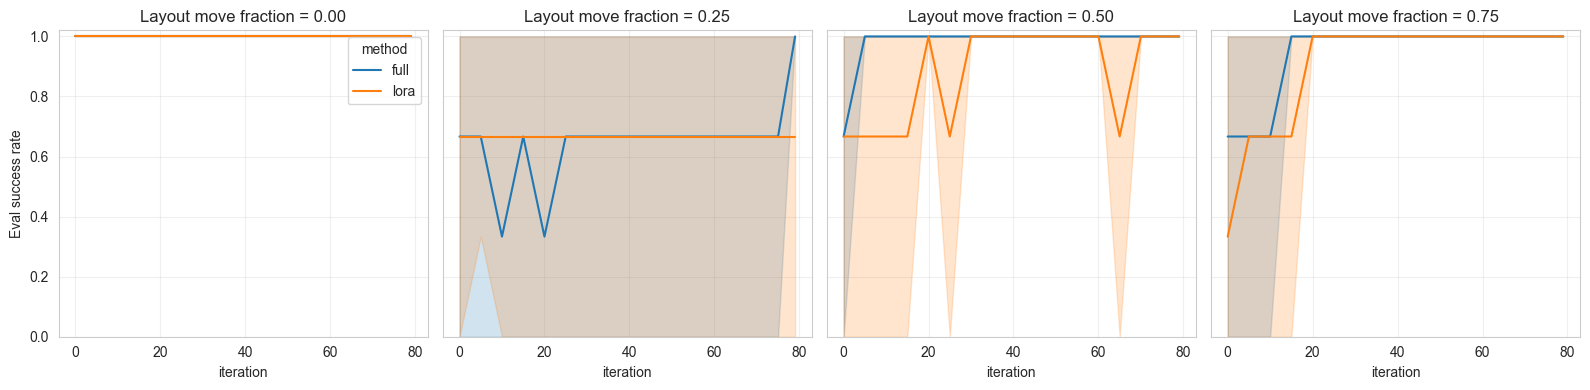

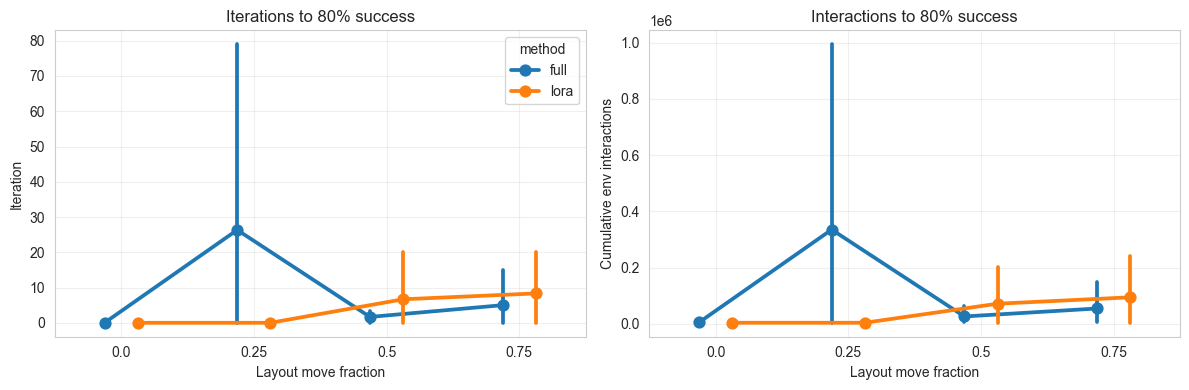

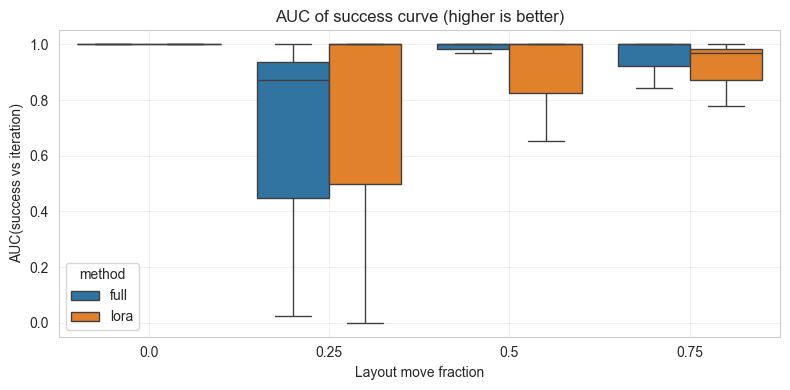

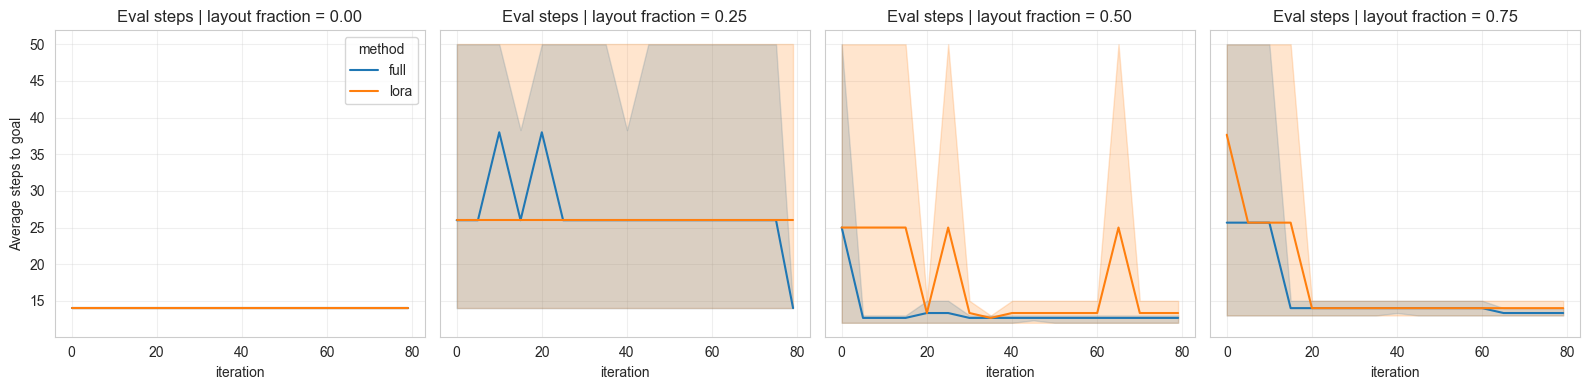

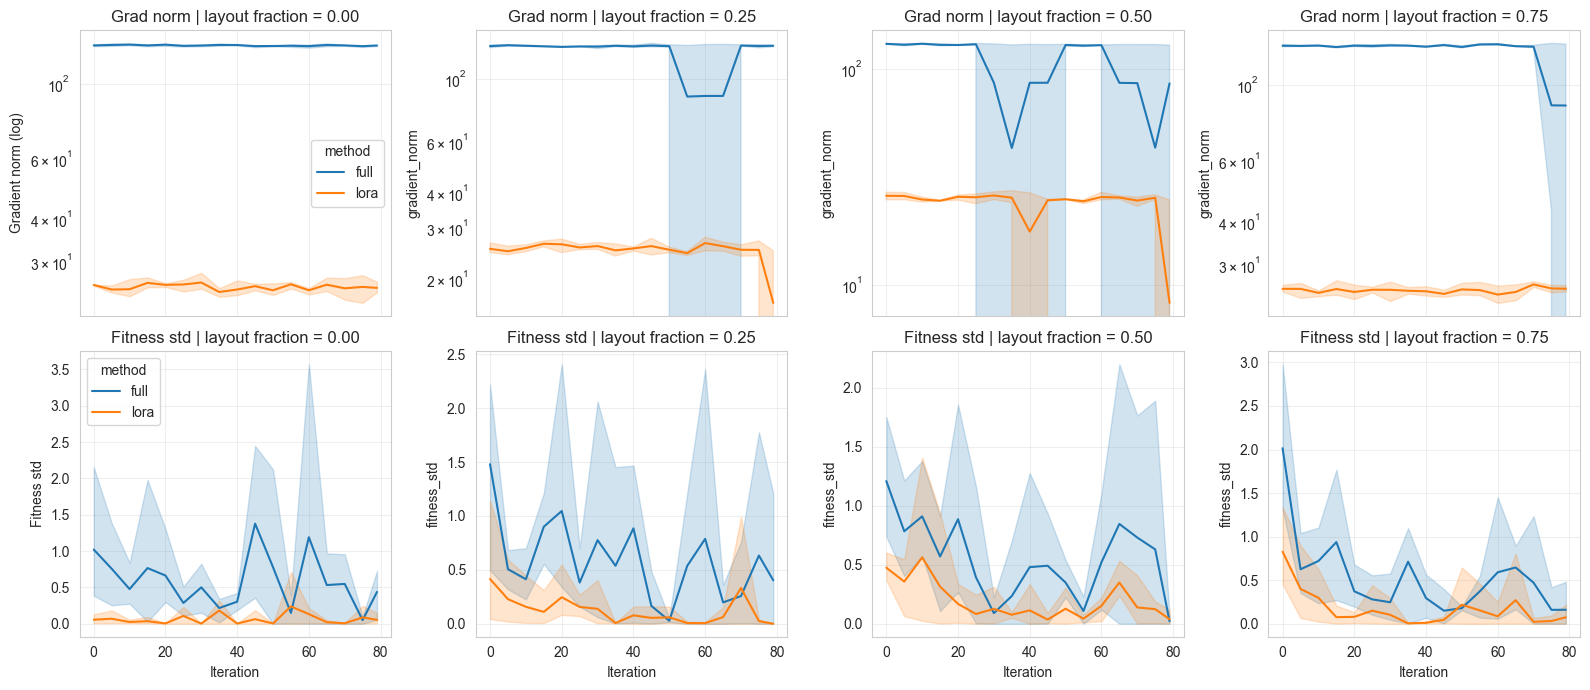

In [ ]:
def _history_frame(metric_name: str):
    rows = []
    for (seed, perturb_std, method), hist in history_store.items():
        n = min(len(hist.get('iteration', [])), len(hist.get(metric_name, [])))
        if n == 0:
            continue

        for idx in range(n):
            rows.append({
                'seed': seed,
                'perturb_std': perturb_std,
                'method': method,
                'iteration': hist['iteration'][idx],
                metric_name: hist[metric_name][idx]
            })
    return pd.DataFrame(rows)


def _plot_or_note_line(ax, df, x, y, hue='method'):
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No non-skipped history data', ha='center', va='center', transform=ax.transAxes)
        ax.grid(True, alpha=0.3)
        return False

    sns.lineplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        estimator='mean',
        errorbar=('ci', 95),
        ax=ax
    )
    ax.grid(True, alpha=0.3)
    return True


if 'run_status' not in results_df.columns:
    results_df['run_status'] = np.where(results_df['skipped_reason'].ne(''), 'skipped', 'ok')

quality_control_summary = (
    results_df
    .groupby(['perturb_std', 'method', 'run_status'])['seed']
    .size()
    .rename('n_runs')
    .reset_index()
    .sort_values(['perturb_std', 'method', 'run_status'])
)
print('Quality-control summary (ok/skipped counts):')
display(quality_control_summary)

plot_results_df = results_df[results_df['run_status'] == 'ok'].copy()
curve_df = _history_frame('eval_success')
steps_curve_df = _history_frame('eval_steps')
grad_curve_df = _history_frame('gradient_norm')
fitstd_curve_df = _history_frame('fitness_std')

from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / '.git').exists():
        repo_root = candidate
        break
if repo_root is None:
    repo_root = cwd
figures_dir = repo_root / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# 1) Adaptation learning curves (eval success)
fig, axes = plt.subplots(1, len(PERTURB_LEVELS), figsize=(4 * len(PERTURB_LEVELS), 4), sharey=True)
if len(PERTURB_LEVELS) == 1:
    axes = [axes]

for i, perturb_std in enumerate(PERTURB_LEVELS):
    ax = axes[i]
    subset = curve_df[curve_df['perturb_std'] == perturb_std]
    has_data = _plot_or_note_line(ax, subset, x='iteration', y='eval_success', hue='method')
    ax.set_title(f'Layout move fraction = {perturb_std:.2f}')
    ax.set_ylim(0.0, 1.02)
    if i > 0 and has_data and ax.get_legend() is not None:
        ax.get_legend().remove()

axes[0].set_ylabel('Eval success rate')
if axes[-1].get_legend() is not None:
    axes[-1].legend(loc='lower right')
plt.tight_layout()
fig.savefig(figures_dir / 'week7_gridworld_eval_success_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) Threshold crossing plot (iterations/interactions to 0.8 success)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if len(plot_results_df):
    sns.pointplot(
        data=plot_results_df,
        x='perturb_std',
        y='time_to_0.8',
        hue='method',
        errorbar=('ci', 95),
        dodge=0.25,
        ax=axes[0]
    )
else:
    axes[0].text(0.5, 0.5, 'No non-skipped runs', ha='center', va='center', transform=axes[0].transAxes)

axes[0].set_title('Iterations to 80% success')
axes[0].set_xlabel('Layout move fraction')
axes[0].set_ylabel('Iteration')
axes[0].grid(True, alpha=0.3)

if len(plot_results_df):
    sns.pointplot(
        data=plot_results_df,
        x='perturb_std',
        y='interactions_to_0.8',
        hue='method',
        errorbar=('ci', 95),
        dodge=0.25,
        ax=axes[1]
    )
else:
    axes[1].text(0.5, 0.5, 'No non-skipped runs', ha='center', va='center', transform=axes[1].transAxes)

axes[1].set_title('Interactions to 80% success')
axes[1].set_xlabel('Layout move fraction')
axes[1].set_ylabel('Cumulative env interactions')
axes[1].grid(True, alpha=0.3)

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
plt.tight_layout()
fig.savefig(figures_dir / 'week7_gridworld_threshold_crossing.png', dpi=300, bbox_inches='tight')
plt.show()

# 3) AUC(success) comparison
fig, ax = plt.subplots(figsize=(8, 4))
if len(plot_results_df):
    sns.boxplot(data=plot_results_df, x='perturb_std', y='auc_success', hue='method', ax=ax)
else:
    ax.text(0.5, 0.5, 'No non-skipped runs', ha='center', va='center', transform=ax.transAxes)
ax.set_title('AUC of success curve (higher is better)')
ax.set_xlabel('Layout move fraction')
ax.set_ylabel('AUC(success vs iteration)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(figures_dir / 'week7_gridworld_auc_success_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 4) Policy quality plot: eval steps (lower is better)
fig, axes = plt.subplots(1, len(PERTURB_LEVELS), figsize=(4 * len(PERTURB_LEVELS), 4), sharey=True)
if len(PERTURB_LEVELS) == 1:
    axes = [axes]

for i, perturb_std in enumerate(PERTURB_LEVELS):
    ax = axes[i]
    subset = steps_curve_df[steps_curve_df['perturb_std'] == perturb_std]
    has_data = _plot_or_note_line(ax, subset, x='iteration', y='eval_steps', hue='method')
    ax.set_title(f'Eval steps | layout fraction = {perturb_std:.2f}')
    if i > 0 and has_data and ax.get_legend() is not None:
        ax.get_legend().remove()

axes[0].set_ylabel('Average steps to goal')
if axes[-1].get_legend() is not None:
    axes[-1].legend(loc='upper right')
plt.tight_layout()
fig.savefig(figures_dir / 'week7_gridworld_eval_steps_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 5) Diagnostic panel: gradient norm + fitness std
fig, axes = plt.subplots(2, len(PERTURB_LEVELS), figsize=(4 * len(PERTURB_LEVELS), 7), sharex=True)
if len(PERTURB_LEVELS) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, perturb_std in enumerate(PERTURB_LEVELS):
    grad_subset = grad_curve_df[grad_curve_df['perturb_std'] == perturb_std]
    std_subset = fitstd_curve_df[fitstd_curve_df['perturb_std'] == perturb_std]

    grad_has_data = _plot_or_note_line(axes[0, i], grad_subset, x='iteration', y='gradient_norm', hue='method')
    axes[0, i].set_title(f'Grad norm | layout fraction = {perturb_std:.2f}')
    axes[0, i].set_yscale('log')

    std_has_data = _plot_or_note_line(axes[1, i], std_subset, x='iteration', y='fitness_std', hue='method')
    axes[1, i].set_title(f'Fitness std | layout fraction = {perturb_std:.2f}')

    if i > 0:
        if grad_has_data and axes[0, i].get_legend() is not None:
            axes[0, i].get_legend().remove()
        if std_has_data and axes[1, i].get_legend() is not None:
            axes[1, i].get_legend().remove()

axes[0, 0].set_ylabel('Gradient norm (log)')
axes[1, 0].set_ylabel('Fitness std')
for i in range(len(PERTURB_LEVELS)):
    axes[1, i].set_xlabel('Iteration')

plt.tight_layout()
fig.savefig(figures_dir / 'week7_gridworld_diagnostics_panel.png', dpi=300, bbox_inches='tight')
plt.show()

## Result Interpretation

Use the table from the next code cell to summarize which method is preferable by perturbation level.

**Decision rule from plan:**
- LoRA preferred when it reaches thresholds at similar/fewer interactions and keeps similar final success.
- Full ES preferred when perturbation is large and LoRA misses high-success thresholds under the same budget.

After running, report:
1. `time_to_0.8` and `interactions_to_0.8` by perturbation level
2. AUC difference (LoRA - Full)
3. Final success difference (LoRA - Full)

In [ ]:
if 'results_df' not in globals():
    raise RuntimeError('results_df not found. Run the adaptation experiment cell first.')

results_df = results_df.copy()
if 'run_status' not in results_df.columns:
    results_df['run_status'] = np.where(results_df['skipped_reason'].ne(''), 'skipped', 'ok')
if 'is_skipped' not in results_df.columns:
    results_df['is_skipped'] = results_df['run_status'].eq('skipped')

valid_df = results_df[results_df['run_status'] == 'ok'].copy()
skip_counts = (
    results_df.groupby(['perturb_std', 'method'])['is_skipped']
    .sum()
    .rename('skipped_runs')
    .reset_index()
)
run_counts = (
    results_df.groupby(['perturb_std', 'method'])['seed']
    .size()
    .rename('total_runs')
    .reset_index()
)

if len(valid_df):
    agg = valid_df.groupby(['perturb_std', 'method']).agg(
        final_eval_success=('final_eval_success', 'mean'),
        final_eval_reward=('final_eval_reward', 'mean'),
        final_eval_steps=('final_eval_steps', 'mean'),
        auc_success=('auc_success', 'mean'),
        time_to_0_8=('time_to_0.8', 'mean'),
        interactions_to_0_8=('interactions_to_0.8', 'mean')
    ).reset_index()
else:
    agg = pd.DataFrame(columns=[
        'perturb_std', 'method', 'final_eval_success', 'final_eval_reward',
        'final_eval_steps', 'auc_success', 'time_to_0_8', 'interactions_to_0_8'
    ])

agg = agg.merge(run_counts, on=['perturb_std', 'method'], how='outer')
agg = agg.merge(skip_counts, on=['perturb_std', 'method'], how='outer')
agg['total_runs'] = agg['total_runs'].fillna(0).astype(int)
agg['skipped_runs'] = agg['skipped_runs'].fillna(0).astype(int)
agg['valid_runs'] = agg['total_runs'] - agg['skipped_runs']
agg['summary_excludes_skipped'] = 1
agg = agg.sort_values(['perturb_std', 'method']).reset_index(drop=True)

delta_rows = []
for perturb_std in sorted(results_df['perturb_std'].unique().tolist()):
    sub = agg[agg['perturb_std'] == perturb_std].set_index('method')
    if ('full' not in sub.index) or ('lora' not in sub.index):
        continue

    delta_rows.append({
        'perturb_std': float(perturb_std),
        'delta_final_success_lora_minus_full': sub.loc['lora', 'final_eval_success'] - sub.loc['full', 'final_eval_success'],
        'delta_auc_lora_minus_full': sub.loc['lora', 'auc_success'] - sub.loc['full', 'auc_success'],
        'delta_time_to_0_8_lora_minus_full': sub.loc['lora', 'time_to_0_8'] - sub.loc['full', 'time_to_0_8'],
        'delta_interactions_to_0_8_lora_minus_full': sub.loc['lora', 'interactions_to_0_8'] - sub.loc['full', 'interactions_to_0_8'],
        'lora_valid_runs': int(sub.loc['lora', 'valid_runs']),
        'full_valid_runs': int(sub.loc['full', 'valid_runs']),
        'delta_excludes_skipped': 1
    })

delta = pd.DataFrame(delta_rows)

print('Method means by perturbation level (skipped runs excluded from metric means):')
display(agg.round(4))

print('Skipped runs by perturbation and method:')
display(skip_counts)

print('LoRA minus Full deltas (negative time/interactions means faster LoRA):')
display(delta.round(4))

print('\nQuick criterion check:')
for _, row in delta.iterrows():
    p = row['perturb_std']
    if row['lora_valid_runs'] == 0 or row['full_valid_runs'] == 0:
        print(f'  layout_fraction={p:.2f}: insufficient non-skipped runs for comparison')
        continue

    faster = row['delta_interactions_to_0_8_lora_minus_full'] <= 0
    competitive = row['delta_final_success_lora_minus_full'] >= -0.05
    if faster and competitive:
        verdict = 'LoRA favorable at this perturbation level'
    else:
        verdict = 'Full ES likely favorable at this perturbation level'
    print(f'  layout_fraction={p:.2f}: {verdict}')

Method means by perturbation level (skipped runs excluded from metric means):


,perturb_std,method,final_eval_success,final_eval_reward,final_eval_steps,auc_success,time_to_0_8,interactions_to_0_8,total_runs,skipped_runs,valid_runs,summary_excludes_skipped
0,0.00,full,1.0000,1.0000,14.0000,1.0000,0.0000,4786.0000,3,0,3,1
1,0.00,lora,1.0000,1.0000,14.0000,1.0000,0.0000,3753.6667,3,0,3,1
2,0.25,full,1.0000,1.0000,14.0000,0.6329,26.3333,334908.3333,3,0,3,1
3,0.25,lora,0.6667,0.6667,26.0000,0.6667,0.0000,3737.0000,3,0,3,1
4,0.50,full,1.0000,1.0000,12.6667,0.9895,1.6667,26099.0000,3,0,3,1
5,0.50,lora,1.0000,1.0000,13.3333,0.8840,6.6667,71407.6667,3,0,3,1
6,0.75,full,1.0000,1.0000,13.3333,0.9473,5.0000,54432.3333,3,0,3,1
7,0.75,lora,1.0000,1.0000,14.0000,0.9156,8.3333,94242.3333,3,0,3,1


Skipped runs by perturbation and method:


,perturb_std,method,skipped_runs
0,0.00,full,0
1,0.00,lora,0
2,0.25,full,0
3,0.25,lora,0
4,0.50,full,0
5,0.50,lora,0
6,0.75,full,0
7,0.75,lora,0


LoRA minus Full deltas (negative time/interactions means faster LoRA):


,perturb_std,delta_final_success_lora_minus_full,delta_auc_lora_minus_full,delta_time_to_0_8_lora_minus_full,delta_interactions_to_0_8_lora_minus_full,lora_valid_runs,full_valid_runs,delta_excludes_skipped
0,0.00,0.0000,0.0000,0.0000,-1032.3333,3,3,1
1,0.25,-0.3333,0.0338,-26.3333,-331171.3333,3,3,1
2,0.50,0.0000,-0.1055,5.0000,45308.6667,3,3,1
3,0.75,0.0000,-0.0316,3.3333,39810.0000,3,3,1



Quick criterion check:
  layout_fraction=0.00: LoRA favorable at this perturbation level
  layout_fraction=0.25: Full ES likely favorable at this perturbation level
  layout_fraction=0.50: Full ES likely favorable at this perturbation level
  layout_fraction=0.75: Full ES likely favorable at this perturbation level


### Export Results to CSV

Run this after the experiment cells to save both run-level and summary tables for reporting.

In [ ]:
from pathlib import Path

if 'results_df' not in globals():
    raise RuntimeError('results_df not found. Run the adaptation experiment cell first.')

results_df = results_df.copy()
if 'run_status' not in results_df.columns:
    results_df['run_status'] = np.where(results_df['skipped_reason'].ne(''), 'skipped', 'ok')
if 'is_skipped' not in results_df.columns:
    results_df['is_skipped'] = results_df['run_status'].eq('skipped')

if 'agg' not in globals():
    valid_df = results_df[~results_df['is_skipped']].copy()
    skip_counts = (
        results_df.groupby(['perturb_std', 'method'])['is_skipped']
        .sum()
        .rename('skipped_runs')
        .reset_index()
    )
    run_counts = (
        results_df.groupby(['perturb_std', 'method'])['seed']
        .size()
        .rename('total_runs')
        .reset_index()
    )

    if len(valid_df):
        agg = valid_df.groupby(['perturb_std', 'method']).agg(
            final_eval_success=('final_eval_success', 'mean'),
            final_eval_reward=('final_eval_reward', 'mean'),
            final_eval_steps=('final_eval_steps', 'mean'),
            auc_success=('auc_success', 'mean'),
            time_to_0_8=('time_to_0.8', 'mean'),
            interactions_to_0_8=('interactions_to_0.8', 'mean')
        ).reset_index()
    else:
        agg = pd.DataFrame(columns=[
            'perturb_std', 'method', 'final_eval_success', 'final_eval_reward',
            'final_eval_steps', 'auc_success', 'time_to_0_8', 'interactions_to_0_8'
        ])

    agg = agg.merge(run_counts, on=['perturb_std', 'method'], how='outer')
    agg = agg.merge(skip_counts, on=['perturb_std', 'method'], how='outer')
    agg['total_runs'] = agg['total_runs'].fillna(0).astype(int)
    agg['skipped_runs'] = agg['skipped_runs'].fillna(0).astype(int)
    agg['valid_runs'] = agg['total_runs'] - agg['skipped_runs']
    agg['summary_excludes_skipped'] = 1

if 'delta' not in globals():
    delta_rows = []
    for perturb_std in sorted(results_df['perturb_std'].unique().tolist()):
        sub = agg[agg['perturb_std'] == perturb_std].set_index('method')
        if ('full' not in sub.index) or ('lora' not in sub.index):
            continue

        delta_rows.append({
            'perturb_std': float(perturb_std),
            'delta_final_success_lora_minus_full': sub.loc['lora', 'final_eval_success'] - sub.loc['full', 'final_eval_success'],
            'delta_auc_lora_minus_full': sub.loc['lora', 'auc_success'] - sub.loc['full', 'auc_success'],
            'delta_time_to_0_8_lora_minus_full': sub.loc['lora', 'time_to_0_8'] - sub.loc['full', 'time_to_0_8'],
            'delta_interactions_to_0_8_lora_minus_full': sub.loc['lora', 'interactions_to_0_8'] - sub.loc['full', 'interactions_to_0_8'],
            'lora_valid_runs': int(sub.loc['lora', 'valid_runs']),
            'full_valid_runs': int(sub.loc['full', 'valid_runs']),
            'delta_excludes_skipped': 1
        })
    delta = pd.DataFrame(delta_rows)

out_dir = Path('results')
out_dir.mkdir(parents=True, exist_ok=True)

run_path = out_dir / 'es_lora_adaptation_runs.csv'
summary_path = out_dir / 'es_lora_adaptation_summary.csv'
delta_path = out_dir / 'es_lora_adaptation_deltas.csv'

results_df.to_csv(run_path, index=False)
agg.to_csv(summary_path, index=False)
delta.to_csv(delta_path, index=False)

print('Saved CSV files:')
print(f'  {run_path.resolve()}')
print(f'  {summary_path.resolve()}')
print(f'  {delta_path.resolve()}')
print('Summary CSV note: metrics exclude skipped runs; counts are reported in total_runs/skipped_runs/valid_runs.')

Saved CSV files:
  C:\Users\jrtam\OneDrive\Desktop\Classes\4Soph Spring\STAT 4830\STAT-4830-project-base\notebooks\results\es_lora_adaptation_runs.csv
  C:\Users\jrtam\OneDrive\Desktop\Classes\4Soph Spring\STAT 4830\STAT-4830-project-base\notebooks\results\es_lora_adaptation_summary.csv
  C:\Users\jrtam\OneDrive\Desktop\Classes\4Soph Spring\STAT 4830\STAT-4830-project-base\notebooks\results\es_lora_adaptation_deltas.csv
Summary CSV note: metrics exclude skipped runs; counts are reported in total_runs/skipped_runs/valid_runs.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def run_episode_frames(policy, env):
    """Run one episode, collecting frames at each step."""
    frames = []
    state = env.reset()
    done = False

    while not done:
        # Capture current grid state
        frames.append({
            'agent': tuple(env.agent_pos),
            'goal': tuple(env.goal_pos),
            'obstacles': set(env.obstacles),
            'size': env.size
        })


        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = policy(state_t)
            action = torch.argmax(logits, dim=-1).item()

        state, _, done, _ = env.step(action)

    frames.append({
        'agent': tuple(env.agent_pos),
        'goal': tuple(env.goal_pos),
        'obstacles': set(env.obstacles),
        'size': env.size
    })
    return frames


def make_grid_animation(frames, title="GridWorld Agent"):
    fig, ax = plt.subplots(figsize=(5, 5))

    def draw_frame(i):
        ax.clear()
        f = frames[i]
        size = f['size']
        grid = np.zeros((size, size, 3))

        grid[:, :, :] = 1.0

        for (r, c) in f['obstacles']:
            grid[size - 1 - r, c] = [0.9, 0.4, 0.4]

        gr, gc = f['goal']
        grid[size - 1 - gr, gc] = [0.4, 0.85, 0.4]

        ax.imshow(grid, interpolation='nearest')

        ar, ac = f['agent']
        ax.plot(ac, size - 1 - ar, 'o', color='#2255cc',
                markersize=14, markeredgecolor='white', markeredgewidth=1.5)

        for x in range(size + 1):
            ax.axhline(x - 0.5, color='gray', linewidth=0.5)
            ax.axvline(x - 0.5, color='gray', linewidth=0.5)

        ax.set_xlim(-0.5, size - 0.5)
        ax.set_ylim(-0.5, size - 0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{title} — step {i}/{len(frames)-1}", fontsize=11)

    ani = animation.FuncAnimation(
        fig, draw_frame, frames=len(frames),
        interval=300, repeat=True
    )
    plt.close(fig)
    return ani



demo_seed = SEEDS[0]
_, demo_env = make_source_envs(demo_seed)

frames = run_episode_frames(pretrained_policy_full, demo_env)
ani = make_grid_animation(frames, title="Pretrained ES agent")

HTML(ani.to_jshtml())